# 10.2.注意力汇聚：Nadaraya-Watson 核回归

上节介绍了框架下的注意力机制的主要成分 图10.1.3： 查询（自主提示）和键（非自主提示）之间的交互形成了注意力汇聚； 注意力汇聚有选择地聚合了值（感官输入）以生成最终的输出。 本节将介绍注意力汇聚的更多细节， 以便从宏观上了解注意力机制在实践中的运作方式。 具体来说，1964年提出的 Nadaraya-Watson核回归模型 ([Nadaraya, 1964](https://zh.d2l.ai/chapter_references/zreferences.html#Nadaraya.1964) and [Watson, 1964](https://zh.d2l.ai/chapter_references/zreferences.html#Watson.1964))是一个简单而完整的例子， 可以用于演示具有注意力机制的机器学习。

## 10.2.1.环境配置

本节需要在昇腾 NPU 上运行 pypto 算子（exp / softmax / bmm），因此需先完成 pypto 环境初始化。

In [1]:
%pip install pypto==0.2.1 torch torch_npu matplotlib

In [2]:
import os
os.environ["TILE_FWK_DEVICE_ID"] = "0"
import warnings
warnings.filterwarnings("ignore", message="Permission mismatch")
warnings.filterwarnings("ignore", message="TASK_QUEUE_ENABLE")
warnings.filterwarnings("ignore", message="On the interactive interface")
warnings.filterwarnings("ignore", message="Cannot create tensor")
import pypto
import torch
from torch import nn
from torch.nn import functional as F
import torch_npu
import logging
logging.getLogger("matplotlib").setLevel(logging.WARNING)
import matplotlib.pyplot as plt

device_id = int(os.environ["TILE_FWK_DEVICE_ID"])
torch.npu.set_device(device_id)
device = f"npu:{device_id}"
pypto.pypto_impl.DeviceInit()

## 10.2.2.生成数据集

简单起见，考虑下面这个回归问题： 给定的成对的"输入－输出"数据集 $\{(x_1, y_1), \ldots, (x_n, y_n)\}$， 如何学习$f$来预测任意新输入$x$的输出$\hat{y} = f(x)$？

根据下面的非线性函数生成一个人工数据集， 其中噪音项$\epsilon$服从均值为$0$和标准差为$0.5$的正态分布：

$$
y_i = 2\sin(x_i) + x_i^{0.8} + \epsilon, \tag{10.2.1}
$$

其中$\epsilon$服从均值为$0$和标准差为$0.5$的正态分布。 在这里生成了$50$个训练样本和$50$个测试样本。 为了更好地可视化之后的注意力模式， 我们将训练样本的输入按升序排列。

In [3]:
n_train = 50  # 训练样本数
x_train, _ = torch.sort(torch.rand(n_train) * 5)   # 排序后的训练样本

def f(x):
    return 2 * torch.sin(x) + x**0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))  # 训练样本的输出
x_test = torch.arange(0, 5, 0.1)  # 测试样本
y_truth = f(x_test)  # 测试样本的真实输出
n_test = len(x_test)  # 测试样本数
n_test

50

下面的函数将绘制所有的训练样本（样本由圆圈表示）， 不带噪声项的真实数据生成函数$f$（标记为"Truth"）， 以及学习得到的预测函数（标记为"Pred"）。`plot_kernel_reg` 使用 `src.utils` 中的 `plot` 函数（Matplotlib 实现，替代 `d2l.plot`）绘制曲线。

In [4]:
from src.utils import plot, show_heatmaps

def plot_kernel_reg(y_hat):
    _, axes = plt.subplots(1, 1, figsize=(3.5, 2.5))
    axes.plot(x_test, y_truth, '-', label='Truth')
    axes.plot(x_test, y_hat, 'm--', label='Pred')
    axes.plot(x_train, y_train, 'o', alpha=0.5)
    axes.set_xlabel('x')
    axes.set_ylabel('y')
    axes.set_xlim([0, 5])
    axes.set_ylim([-1, 5])
    axes.legend(['Truth', 'Pred'])
    axes.grid()
    plt.show()

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def plot_kernel_reg(y_hat):
    d2l.plot(x_test, [y_truth, y_hat], &#x27;x&#x27;, &#x27;y&#x27;, legend=[&#x27;Truth&#x27;, &#x27;Pred&#x27;],
             xlim=[0, 5], ylim=[-1, 5])
    d2l.plt.plot(x_train, y_train, &#x27;o&#x27;, alpha=0.5);
    </pre>
  </div>
</details>

## 10.2.3.平均汇聚

先使用最简单的估计器来解决回归问题。 基于平均汇聚来计算所有训练样本输出值的平均值：

$$f(x) = \frac{1}{n}\sum_{i=1}^n y_i, \tag{10.2.2}$$

如下图所示，这个估计器确实不够聪明。 真实函数$f$（"Truth"）和预测函数（"Pred"）相差很大。

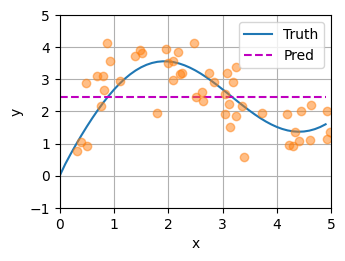

In [5]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

## 10.2.4.非参数注意力汇聚

显然，平均汇聚忽略了输入$x_i$。 于是Nadaraya ([Nadaraya, 1964](https://zh.d2l.ai/chapter_references/zreferences.html#Nadaraya.1964))和 Watson ([Watson, 1964](https://zh.d2l.ai/chapter_references/zreferences.html#Watson.1964))提出了一个更好的想法， 根据输入的位置对输出$y_i$进行加权：

$$f(x) = \sum_{i=1}^n \alpha(x, x_i) y_i, \tag{10.2.3}$$

其中$\alpha(x, x_i)$是查询$x$和键$x_i$之间的注意力权重。 对于Nadaraya-Watson核回归，注意力权重是下面给出的高斯核（Gaussian kernel）：

$$\alpha(x, x_i) = \frac{\exp\left(-\frac{1}{2}(x - x_i)^2\right)}{\sum_{j=1}^n \exp\left(-\frac{1}{2}(x - x_j)^2\right)}. \tag{10.2.4}$$

直观而言，上式中的注意力权重在测试样本距离查询点越近时，注意力权重越高。

## 10.2.5.注意力专用算子：exp、softmax 和 bmm

注意力汇聚（加权平均）依赖三个核心算子：**exp**（高斯核）、**softmax**（权重归一化）和 **bmm**（批量矩阵乘法，完成加权平均）。

- `exp`：高斯核 $\exp(-\frac{1}{2}(x - x_i)^2)$；
- `softmax`：与 `exp` 组合后等价于对权重归一化（d2l 原文直接用 `softmax(-(X-x)^2/2)`）；
- `bmm`：批量小矩阵乘法，用于把 `(n_test, n_train, 1)` 的权重与值批量相乘，得到加权平均。

softmax 的 fwd/bwd kernel 与第 [9.7 节](../09_pypto_modern_recurrent_neural_networks/09.07_seq2seq.ipynb) 融合 Softmax+CE 中的实现共用（UB 是 AI Core 的片上向量工作区，容量有限，tile 切得过大容易溢出；vec 行 tile 为 128，列数较大时自动降为 64 行、超大时退回 8 行以保护 UB 空间）；为保持教学完整性，本节将内联展示 `bmm`、`softmax`、`exp` 三个算子的完整 Kernel + 工厂函数链条（每个算子占一个代码单元，最后统一实例化），帮助读者看清注意力机制在 NPU 上的完整工作流。后续小节（[10.3 节](10.03_attention_scoring_functions.ipynb)起）将直接从 `src.pypto_ops` 导入，不再重复。

In [6]:
# ── bmm：批量矩阵乘法 C = A @ B，A/B/C 形状为 (batch, M, K)/(batch, K, N)/(batch, M, N) ──
# ── 反向：grad_A = grad_C @ B^T, grad_B = A^T @ grad_C ──
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def bmm_fwd_kernel(
    a: pypto.Tensor([], pypto.DT_FP32),
    b: pypto.Tensor([], pypto.DT_FP32),
    c: pypto.Tensor([], pypto.DT_FP32),
    bsz: int,
    m: int,
    k: int,
    n: int,
):
    pypto.set_cube_tile_shapes([128, 128], [64, 128], [128, 128])
    pypto.set_vec_tile_shapes(128, 128)
    for i in pypto.loop(bsz, name="LOOP_b", idx_name="i"):
        ai = pypto.view(a, [m, k], [i * m, 0])
        bi = pypto.view(b, [k, n], [i * k, 0])
        ci = pypto.matmul(ai, bi, pypto.DT_FP32)
        pypto.assemble(ci, [i * m, 0], c)

@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def bmm_bwd_kernel(
    a: pypto.Tensor([], pypto.DT_FP32),
    b: pypto.Tensor([], pypto.DT_FP32),
    grad_c: pypto.Tensor([], pypto.DT_FP32),
    grad_a: pypto.Tensor([], pypto.DT_FP32),
    grad_b: pypto.Tensor([], pypto.DT_FP32),
    bsz: int,
    m: int,
    k: int,
    n: int,
):
    pypto.set_cube_tile_shapes([128, 128], [64, 128], [128, 128])
    pypto.set_vec_tile_shapes(128, 128)
    for i in pypto.loop(bsz, name="LOOP_b", idx_name="i"):
        ai = pypto.view(a, [m, k], [i * m, 0])
        bi = pypto.view(b, [k, n], [i * k, 0])
        gci = pypto.view(grad_c, [m, n], [i * m, 0])
        gai = pypto.matmul(gci, bi, pypto.DT_FP32, b_trans=True)
        gbi = pypto.matmul(ai, gci, pypto.DT_FP32, a_trans=True)
        pypto.assemble(gai, [i * m, 0], grad_a)
        pypto.assemble(gbi, [i * k, 0], grad_b)

def make_pypto_bmm(fwd_kernel, bwd_kernel):
    class PyPTOBMMImpl(torch.autograd.Function):
        @staticmethod
        def forward(ctx, a, b):
            ctx.save_for_backward(a, b)
            bsz, m, k = a.shape
            n = b.shape[-1]
            # 3 维 → 2 维视图（reshape 本身零拷贝；.contiguous() 仅在输入非连续时产生拷贝）：
            # (B,M,K)→(B*M,K)、(B,K,N)→(B*K,N)
            a2 = a.reshape(bsz * m, k).contiguous()
            b2 = b.reshape(bsz * k, n).contiguous()
            c2 = torch.empty(bsz * m, n, device=a.device, dtype=a.dtype)
            fwd_kernel(a2, b2, c2, bsz, m, k, n)
            return c2.reshape(bsz, m, n)

        @staticmethod
        def backward(ctx, grad_c):
            a, b = ctx.saved_tensors
            need_a = ctx.needs_input_grad[0]
            need_b = ctx.needs_input_grad[1]
            bsz, m, k = a.shape
            n = b.shape[-1]
            a2 = a.reshape(bsz * m, k).contiguous()
            b2 = b.reshape(bsz * k, n).contiguous()
            gc2 = grad_c.reshape(bsz * m, n).contiguous()
            grad_a = torch.empty_like(a) if need_a else None
            grad_b = torch.empty_like(b) if need_b else None
            tmp_a = grad_a.reshape(bsz * m, k) if need_a \
                else torch.empty_like(a2)
            tmp_b = grad_b.reshape(bsz * k, n) if need_b \
                else torch.empty_like(b2)
            if need_a or need_b:
                bwd_kernel(a2, b2, gc2, tmp_a, tmp_b, bsz, m, k, n)
            return grad_a, grad_b

    return PyPTOBMMImpl

In [7]:
# ── softmax（独立版）：y = softmax(x, dim=-1)，任意维度，内部展平为 2D ──
# ── 反向：grad_x = y ⊙ grad_y - y ⊙ sum(y ⊙ grad_y, axis=-1) ──
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def softmax_fwd_kernel(
    x: pypto.Tensor([], pypto.DT_FP32),
    y: pypto.Tensor([], pypto.DT_FP32),
    num_classes: int,
):
    cols = ((num_classes + 7) // 8) * 8
    rows = 128 if cols <= 160 else (64 if cols <= 320 else 8)
    pypto.set_vec_tile_shapes(rows, cols)
    y.move(pypto.softmax(x, dim=-1))

@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def softmax_bwd_kernel(
    y: pypto.Tensor([], pypto.DT_FP32),
    grad_y: pypto.Tensor([], pypto.DT_FP32),
    grad_x: pypto.Tensor([], pypto.DT_FP32),
    num_classes: int,
):
    cols = ((num_classes + 7) // 8) * 8
    rows = 128 if cols <= 160 else (64 if cols <= 320 else 8)
    pypto.set_vec_tile_shapes(rows, cols)
    diag = pypto.mul(y, grad_y)
    s = pypto.sum(diag, 1, True)
    grad_x.move(pypto.sub(diag, pypto.mul(y, s)))
def make_pypto_softmax(fwd_kernel, bwd_kernel):
    class PyPTOSoftmaxImpl(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x):
            orig_shape = x.shape
            num_classes = x.shape[-1]
            x_2d = x.reshape(-1, num_classes).contiguous()
            y_2d = torch.empty_like(x_2d)
            fwd_kernel(x_2d, y_2d, num_classes)
            y = y_2d.reshape(orig_shape)
            ctx.save_for_backward(y)
            return y

        @staticmethod
        def backward(ctx, grad_y):
            (y,) = ctx.saved_tensors
            num_classes = y.shape[-1]
            y_2d = y.reshape(-1, num_classes).contiguous()
            grad_y_2d = grad_y.reshape(-1, num_classes).contiguous()
            grad_x_2d = torch.empty_like(y_2d)
            bwd_kernel(y_2d, grad_y_2d, grad_x_2d, num_classes)
            return grad_x_2d.reshape(y.shape)

    return PyPTOSoftmaxImpl

In [8]:
# ── exp：y = exp(x)，反向：grad_x = exp(x) ⊙ grad_y = y ⊙ grad_y ──
@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def exp_fwd_kernel(
    a: pypto.Tensor([], pypto.DT_FP32),
    b: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    b.move(pypto.exp(a))

@pypto.frontend.jit(runtime_options={"run_mode": pypto.RunMode.NPU})
def exp_bwd_kernel(
    b: pypto.Tensor([], pypto.DT_FP32),
    grad_b: pypto.Tensor([], pypto.DT_FP32),
    grad_a: pypto.Tensor([], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(128, 128)
    grad_a.move(pypto.mul(grad_b, b))

def make_pypto_exp(fwd_kernel, bwd_kernel):
    class PyPTOExpImpl(torch.autograd.Function):
        @staticmethod
        def forward(ctx, a):
            b = torch.empty_like(a)
            fwd_kernel(a, b)
            ctx.save_for_backward(b)
            return b

        @staticmethod
        def backward(ctx, grad_b):
            (b,) = ctx.saved_tensors
            grad_a = torch.empty_like(b) if ctx.needs_input_grad[0] else None
            if grad_a is not None:
                bwd_kernel(b.contiguous(), grad_b.contiguous(), grad_a)
            return grad_a

    return PyPTOExpImpl

In [9]:
# ── 实例化算子 ──
PyPTOBMM = make_pypto_bmm(bmm_fwd_kernel, bmm_bwd_kernel)
PyPTOSoftmax = make_pypto_softmax(softmax_fwd_kernel, softmax_bwd_kernel)
PyPTOExp = make_pypto_exp(exp_fwd_kernel, exp_bwd_kernel)

<details class="code-note" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f9f9fb; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠代码说明</summary>
  <div class="code-note-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <ul style="margin: 0; padding-left: 20px;">
      <li style="margin: 0 0 8px 0;"><b>bmm 算子</b>：参考 pypto 官方仓库（gitcode.com/cann/pypto）的成熟实现——<code>models/glm_v4_5/glm_attention.py</code>（GLM-4.5 Flash Attention）与 <code>examples/03_advanced/advanced_nn/attention/attention.py</code> 均采用 <code>loop + view + assemble</code> 写法——宿主侧把 3 维张量 reshape 为 2 维视图（零拷贝），kernel 内用 <code>pypto.loop</code> 逐 batch <code>pypto.view</code> 切出 2D 切片做 2D matmul，再 <code>pypto.assemble</code> 写回（避免 pypto 0.2.x 对 3 维批量 matmul 的 batch 循环超线性开销，实测快 12 倍）；反向在同一次核调用中计算 <code>grad_a = grad_c @ B^T</code> 与 <code>grad_b = A^T @ grad_c</code>。2D matmul 需同时配置 cube tile shapes（M/N/K 轴）与 vec tile shapes。</li>
      <li style="margin: 0 0 8px 0;"><b>softmax 算子</b>：fwd 使用 <code>pypto.softmax(x, dim=-1)</code>；反向利用恒等式 <code>dx = y⊙dy - y⊙Σ(y⊙dy)</code>，前向输出 <code>y</code> 直接作为反向输入。为支持任意维度，autograd 包装内部将输入展平为 2D <code>(rows, num_classes)</code> 再调用 kernel。vec 行 tile 取 128（实测比 8 行快约 5 倍），UB 保护：cols ≤ 160 用 128 行、cols ≤ 320 用 64 行、更大退回 8 行。</li>
      <li style="margin: 0 0 8px 0;"><b>exp 算子</b>：fwd 使用 <code>pypto.exp(a)</code>；反向由于 <code>d(exp x)/dx = exp x</code>，直接复用前向输出 <code>b</code> 计算 <code>grad_a = grad_b ⊙ b</code>。</li>
      <li style="margin: 0 0 8px 0;">这三个算子已收录在 <code>src/pypto_ops.py</code>（<code>PyPTOBMM / PyPTOSoftmax / PyPTOExp</code>），后续小节直接从 <code>src.pypto_ops</code> 导入。</li>
    </ul>
  </div>
</details>


下面，我们按公式实现非参数注意力汇聚：高斯核的指数部分 $\exp(-\frac{1}{2}(x - x_i)^2)$ 正是 10.2.5 介绍的 `exp` 算子，这里用 `PyPTOSoftmax` 对 $-(x-x_i)^2/2$ 直接逐行归一化，得到与 d2l 原文 `softmax(-(X-x)^2/2)` 完全一致的注意力权重。其中 `X_repeat` 的每一行都是同一个测试输入（查询），`attention_weights` 的形状为 `(n_test, n_train)`，每一行是要在给定查询的各值（`y_train`）之间分配的注意力权重；`y_hat` 的每个元素都是值的加权平均值，权重即注意力权重，用 `PyPTOBMM` 批量完成。

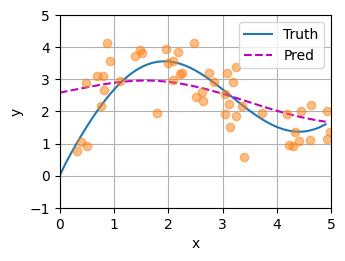

In [10]:
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train)).to(device)
x_train_d = x_train.to(device)
# 高斯核的 logits：-0.5*(x - xi)^2（指数部分即 10.2.5 的 exp 算子），
# 用 PyPTOSoftmax 逐行归一化得到注意力权重（与 d2l 原文
# softmax(-(X-x)^2/2) 一致），形状:(n_test,n_train)
attention_weights = PyPTOSoftmax.apply(-0.5 * (X_repeat - x_train_d) ** 2)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
values = y_train.repeat(n_test).reshape(-1, n_train).to(device)
y_hat = PyPTOBMM.apply(attention_weights.unsqueeze(1),
                       values.unsqueeze(-1)).reshape(-1)
plot_kernel_reg(y_hat.detach().cpu())

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
# X_repeat的形状:(n_test,n_train),
# 每一行都包含着相同的测试输入（例如：同样的查询）
X_repeat = x_test.repeat_interleave(n_train).reshape((-1, n_train))
# x_train包含着键。attention_weights的形状：(n_test,n_train),
# 每一行都包含着要在给定的每个查询的值（y_train）之间分配的注意力权重
attention_weights = nn.functional.softmax(-(X_repeat - x_train)**2 / 2, dim=1)
# y_hat的每个元素都是值的加权平均值，其中的权重是注意力权重
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)
    </pre>
  </div>
</details>

现在来观察注意力的权重。 这里测试数据的输入相当于查询，而训练数据的输入相当于键。 因为两个输入都是经过排序的，因此由观察可知"查询-键"对越接近， 注意力汇聚的**注意力权重**就越高。

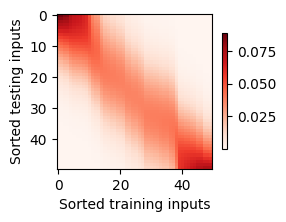

In [11]:
show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel='Sorted training inputs',
                  ylabel='Sorted testing inputs')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
d2l.show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel=&#x27;Sorted training inputs&#x27;,
                  ylabel=&#x27;Sorted testing inputs&#x27;)
    </pre>
  </div>
</details>

## 10.2.6.多种核函数

上面只使用了高斯核 $\alpha(x, x_i) = \exp(-\frac{1}{2}(x - x_i)^2)$。实际上，注意力汇聚（核回归）中的核并不唯一，常用核还包括：

$$
\begin{aligned} \alpha(\mathbf{q}, \mathbf{k}) & = \exp\left(-\frac{1}{2} \|\mathbf{q} - \mathbf{k}\|^2 \right) && \textrm{高斯核;} \\ \alpha(\mathbf{q}, \mathbf{k}) & = 1 \textrm{ 若 } \|\mathbf{q} - \mathbf{k}\| \leq 1 && \textrm{矩形窗核;} \\ \alpha(\mathbf{q}, \mathbf{k}) & = \mathop{\mathrm{max}}\left(0, 1 - \|\mathbf{q} - \mathbf{k}\|\right) && \textrm{Epanechikov 核.} \end{aligned} \tag{10.2.5}
$$

这部分内容来自英文版 [11.2 节](https://d2l.ai/chapter_attention-mechanisms-and-transformers/attention-pooling.html)（中文版 10.2 仅保留高斯核），可作为拓展阅读。注意英文版使用不同的数据生成函数 $y = 2\sin(x) + x + \epsilon$（$\epsilon \sim \mathcal{N}(0, 1)$，40 个训练样本），本节沿用该数据以便与英文版对照。

不同核对应不同的"关注范围"与平滑程度：矩形窗核（boxcar）对距离不超过 1 的键等权参与；常数核（constant）等价于对所有键等权（即平均汇聚）；Epanechikov 核随距离线性衰减。高斯核是其中唯一由 `PyPTOExp` 算子计算的核，其余核用 torch 的比较/最大值算子实现（逐元素、非训练部分）。

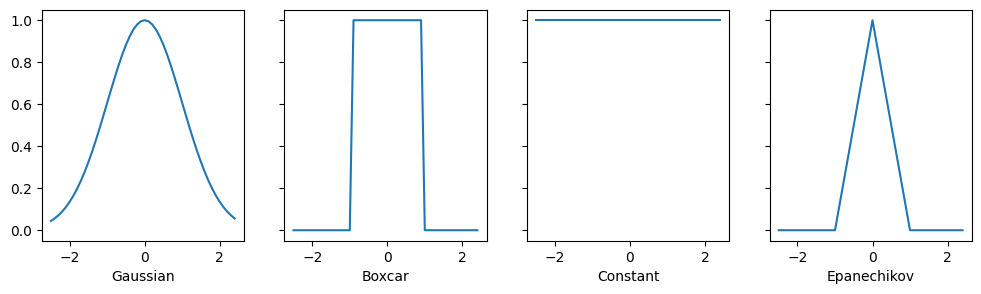

In [12]:
# 高斯核（PyPTO exp 算子）
def gaussian(x):
    return PyPTOExp.apply(-x**2 / 2)

# 矩形窗核：距离不超过 1 的键等权参与
def boxcar(x):
    return torch.abs(x) < 1.0

# 常数核：所有键等权（等价于平均汇聚）
def constant(x):
    return 1.0 + 0 * x

# Epanechikov 核：随距离线性衰减
def epanechikov(x):
    return torch.max(1 - torch.abs(x), torch.zeros_like(x))

fig, axes = plt.subplots(1, 4, sharey=True, figsize=(12, 3))
kernels = (gaussian, boxcar, constant, epanechikov)
names = ('Gaussian', 'Boxcar', 'Constant', 'Epanechikov')
x = torch.arange(-2.5, 2.5, 0.1, device=device)
for kernel, name, ax in zip(kernels, names, axes):
    ax.plot(x.detach().cpu().numpy(), kernel(x).detach().cpu().numpy())
    ax.set_xlabel(name)
plt.show()

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
# Define some kernels
def gaussian(x):
    return torch.exp(-x**2 / 2)
def boxcar(x):
    return torch.abs(x) &lt; 1.0
def constant(x):
    return 1.0 + 0 * x
def epanechikov(x):
    return torch.max(1 - torch.abs(x), torch.zeros_like(x))
fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))
kernels = (gaussian, boxcar, constant, epanechikov)
names = (&#x27;Gaussian&#x27;, &#x27;Boxcar&#x27;, &#x27;Constant&#x27;, &#x27;Epanechikov&#x27;)
x = torch.arange(-2.5, 2.5, 0.1)
for kernel, name, ax in zip(kernels, names, axes):
    ax.plot(x.detach().numpy(), kernel(x).detach().numpy())
    ax.set_xlabel(name)
d2l.plt.show()
    </pre>
  </div>
</details>

下面用这四种核分别做核回归：对每个测试输入（查询），先计算它与所有训练输入（键）的核值，再沿键方向归一化得到注意力权重，最后对训练输出（值）做加权平均。

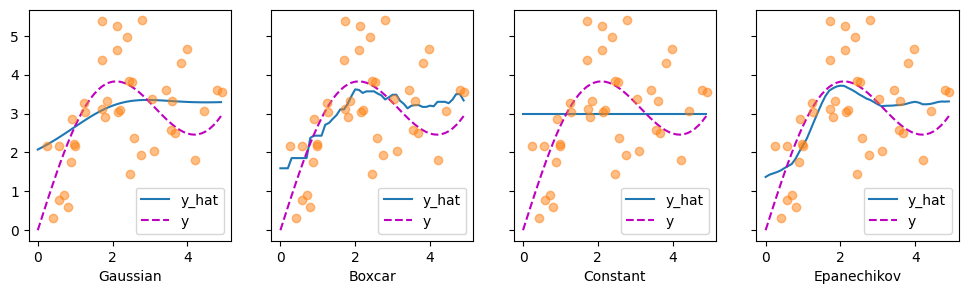

In [13]:
# 英文版 11.2 的数据：y = 2sin(x) + x + ε（ε ~ N(0,1)），40 个训练样本
def f_multi(x):
    return 2 * torch.sin(x) + x

n = 40
x_tr, _ = torch.sort(torch.rand(n) * 5)
y_tr = f_multi(x_tr) + torch.randn(n)
x_te = torch.arange(0, 5, 0.1)
y_te = f_multi(x_te)
x_tr, y_tr = x_tr.to(device), y_tr.to(device)
x_te, y_te = x_te.to(device), y_te.to(device)


def nadaraya_watson(x_tr, y_tr, x_te, kernel):
    # dists 形状：(n_train, n_test)，每一列对应一个查询
    dists = x_tr.reshape((-1, 1)) - x_te.reshape((1, -1))
    k = kernel(dists).type(torch.float32)
    # 沿键方向归一化（每一列对应一个查询）
    attention_w = k / k.sum(0)
    y_hat = y_tr @ attention_w
    return y_hat, attention_w


def plot_multi_kernel(x_tr, y_tr, x_te, y_te, kernels, names, attention=False):
    fig, axes = plt.subplots(1, 4, sharey=True, figsize=(12, 3))
    for kernel, name, ax in zip(kernels, names, axes):
        y_hat, attention_w = nadaraya_watson(x_tr, y_tr, x_te, kernel)
        if attention:
            pcm = ax.imshow(attention_w.detach().cpu().numpy(), cmap='Reds')
        else:
            ax.plot(x_te.detach().cpu().numpy(), y_hat.detach().cpu().numpy())
            ax.plot(x_te.detach().cpu().numpy(), y_te.detach().cpu().numpy(),
                    'm--')
            ax.plot(x_tr.detach().cpu().numpy(), y_tr.detach().cpu().numpy(),
                    'o', alpha=0.5)
            ax.legend(['y_hat', 'y'])
        ax.set_xlabel(name)
    if attention:
        fig.colorbar(pcm, ax=axes, shrink=0.7)
    plt.show()


plot_multi_kernel(x_tr, y_tr, x_te, y_te, kernels, names)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
def f(x):
    return 2 * torch.sin(x) + x
n = 40
x_train, _ = torch.sort(torch.rand(n) * 5)
y_train = f(x_train) + torch.randn(n)
x_val = torch.arange(0, 5, 0.1)
y_val = f(x_val)
def nadaraya_watson(x_train, y_train, x_val, kernel):
    dists = x_train.reshape((-1, 1)) - x_val.reshape((1, -1))
    # Each column/row corresponds to each query/key
    k = kernel(dists).type(torch.float32)
    # Normalization over keys for each query
    attention_w = k / k.sum(0)
    y_hat = y_train@attention_w
    return y_hat, attention_w
def plot(x_train, y_train, x_val, y_val, kernels, names, attention=False):
    fig, axes = d2l.plt.subplots(1, 4, sharey=True, figsize=(12, 3))
    for kernel, name, ax in zip(kernels, names, axes):
        y_hat, attention_w = nadaraya_watson(x_train, y_train, x_val, kernel)
        if attention:
            pcm = ax.imshow(attention_w.detach().numpy(), cmap=&#x27;Reds&#x27;)
        else:
            ax.plot(x_val, y_hat)
            ax.plot(x_val, y_val, &#x27;m--&#x27;)
            ax.plot(x_train, y_train, &#x27;o&#x27;, alpha=0.5);
        ax.set_xlabel(name)
        if not attention:
            ax.legend([&#x27;y_hat&#x27;, &#x27;y&#x27;])
    if attention:
        fig.colorbar(pcm, ax=axes, shrink=0.7)
plot(x_train, y_train, x_val, y_val, kernels, names)
    </pre>
  </div>
</details>

还可以直接观察这四种核对应的**注意力权重**：矩形窗核只对距离不超过 1 的键分配权重（沿对角线的一条窄带），常数核对所有键等权（均匀分布），高斯核与 Epanechikov 核则随距离平滑衰减。

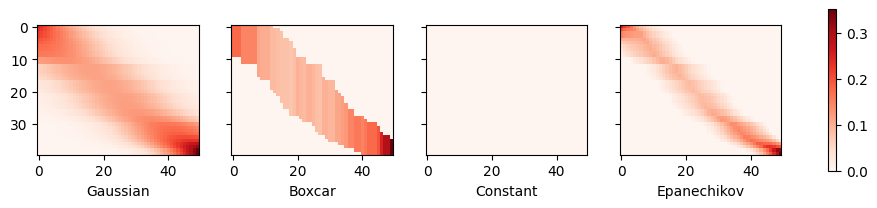

In [14]:
plot_multi_kernel(x_tr, y_tr, x_te, y_te, kernels, names, attention=True)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
plot(x_train, y_train, x_val, y_val, kernels, names, attention=True)
    </pre>
  </div>
</details>

## 10.2.7.带参数注意力汇聚

非参数的Nadaraya-Watson核回归具有*一致性*（consistency）的优点： 如果有足够的数据，此模型会收敛到最优结果。 尽管如此，我们还是可以轻松地将可学习的参数集成到注意力汇聚中。

例如，与 (10.2.4)略有不同， 在下面的查询$x$和键$x_i$之间的距离乘以可学习参数$w$：

$$
\alpha(x, x_i) = \frac{\exp\left(-\frac{1}{2}((x - x_i)w)^2\right)}{\sum_{j=1}^n \exp\left(-\frac{1}{2}((x - x_j)w)^2\right)}. \tag{10.2.6}
$$

下面将介绍这个注意力模型的训练。

**使用小批量矩阵乘法来计算小批量数据中的加权平均值** 之前，让我们先介绍两个小批量矩阵乘法： 第一个小批量矩阵乘法：给定小批量数据 $\mathbf{X} \in \mathbb{R}^{n_1 \times n_2 \times n_3}$ 和 $\mathbf{Y} \in \mathbb{R}^{n_1 \times n_3 \times n_4}$， 输出 $\mathbf{X} \mathbf{Y} \in \mathbb{R}^{n_1 \times n_2 \times n_4}$。 这里我们用 `PyPTOBMM`（自定义批量矩阵乘法算子）替代 `torch.bmm`：

In [15]:
X = torch.ones((2, 1, 4), device=device)
Y = torch.ones((2, 4, 6), device=device)
PyPTOBMM.apply(X, Y).shape

torch.Size([2, 1, 6])

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape
    </pre>
  </div>
</details>

在注意力机制的背景中，我们可以**使用小批量矩阵乘法来计算小批量数据中的加权平均值**。

In [16]:
weights = torch.ones((2, 10), device=device) * 0.1
values = torch.arange(20.0).reshape((2, 10)).to(device)
PyPTOBMM.apply(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]], device='npu:0')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))
    </pre>
  </div>
</details>

### 10.2.7.1.定义模型

基于 (10.2.6)中的 **带参数的注意力汇聚**，使用小批量矩阵乘法， 定义Nadaraya-Watson核回归的带参数版本为：

In [17]:
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))

    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数，"键－值"对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = PyPTOSoftmax.apply(
            -((queries - keys) * self.w)**2 / 2)
        # values的形状为(查询个数，"键－值"对个数)
        return PyPTOBMM.apply(self.attention_weights.unsqueeze(1),
                              values.unsqueeze(-1)).reshape(-1)

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
class NWKernelRegression(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.w = nn.Parameter(torch.rand((1,), requires_grad=True))
    def forward(self, queries, keys, values):
        # queries和attention_weights的形状为(查询个数，&quot;键－值&quot;对个数)
        queries = queries.repeat_interleave(keys.shape[1]).reshape((-1, keys.shape[1]))
        self.attention_weights = nn.functional.softmax(
            -((queries - keys) * self.w)**2 / 2, dim=1)
        # values的形状为(查询个数，&quot;键－值&quot;对个数)
        return torch.bmm(self.attention_weights.unsqueeze(1),
                         values.unsqueeze(-1)).reshape(-1)
    </pre>
  </div>
</details>

### 10.2.7.2.训练

接下来，**将训练数据集变换为键和值**用于训练注意力模型。 在带参数的注意力汇聚模型中， 任何一个训练样本的输入都会和除自己以外的所有训练样本的"键－值"对进行计算， 从而得到其对应的预测输出。

In [18]:
# X_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输入
X_tile = x_train.repeat((n_train, 1))
# Y_tile的形状:(n_train，n_train)，每一行都包含着相同的训练输出
Y_tile = y_train.repeat((n_train, 1))
# keys的形状:('n_train'，'n_train'-1)
keys = X_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))
# values的形状:('n_train'，'n_train'-1)
values = Y_tile[(1 - torch.eye(n_train)).type(torch.bool)].reshape((n_train, -1))

**训练带参数的注意力汇聚模型**时，使用平方损失函数和随机梯度下降。模型与数据都需移动到 NPU；首次反向传播会触发 `bmm_bwd` / `softmax_bwd` kernel 的编译，下面的预热单元会预先触发 JIT 编译，避免训练过程中首次迭代等待。

In [19]:
# 预热：触发训练所需的 bmm/softmax kernel 的首次编译（首次运行编译耗时较长，请耐心等待；
# 编译产物不跨进程复用，重启 notebook 内核后需重新编译）
print("正在编译 pypto kernel（首次运行编译耗时较长，请耐心等待）...")
_X0 = torch.randn(2, 10, 4, device=device, requires_grad=True)
_Y0 = PyPTOSoftmax.apply(PyPTOBMM.apply(_X0, torch.randn(2, 4, 6, device=device)))
_Y0.sum().backward()
print("编译完成。")


正在编译 pypto kernel（首次运行编译耗时较长，请耐心等待）...


编译完成。


最终训练损失 32.779602


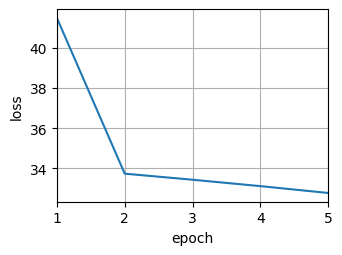

In [20]:
from src.utils import Animator

net = NWKernelRegression().to(device)
loss = nn.MSELoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = Animator(xlabel='epoch', ylabel='loss', xlim=[1, 5])

keys_d, values_d = keys.to(device), values.to(device)
x_train_d, y_train_d = x_train.to(device), y_train.to(device)

for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train_d, keys_d, values_d), y_train_d)
    l.sum().backward()
    trainer.step()
    print(f'epoch {epoch + 1}, loss {float(l.sum().cpu()):.6f}')
    animator.add(epoch + 1, float(l.sum().cpu()))

print(f'最终训练损失 {float(l.sum().cpu()):.6f}')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
net = NWKernelRegression()
loss = nn.MSELoss(reduction=&#x27;none&#x27;)
trainer = torch.optim.SGD(net.parameters(), lr=0.5)
animator = d2l.Animator(xlabel=&#x27;epoch&#x27;, ylabel=&#x27;loss&#x27;, xlim=[1, 5])
for epoch in range(5):
    trainer.zero_grad()
    l = loss(net(x_train, keys, values), y_train)
    l.sum().backward()
    trainer.step()
    print(f&#x27;epoch {epoch + 1}, loss {float(l.sum()):.6f}&#x27;)
    animator.add(epoch + 1, float(l.sum()))
    </pre>
  </div>
</details>

如下所示，训练完带参数的注意力汇聚模型后可以发现： 在尝试拟合带噪声的训练数据时， **预测结果绘制**的线不如之前非参数模型的平滑。

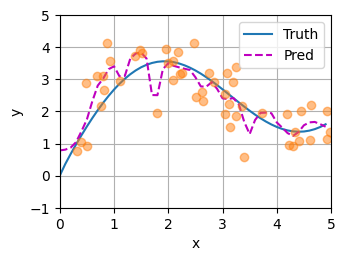

In [21]:
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1)).to(device)
# value的形状:(n_test，n_train)
values = y_train.repeat((n_test, 1)).to(device)
y_hat = net(x_test.to(device), keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat.cpu())

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
# keys的形状:(n_test，n_train)，每一行包含着相同的训练输入（例如，相同的键）
keys = x_train.repeat((n_test, 1))
# value的形状:(n_test，n_train)
values = y_train.repeat((n_test, 1))
y_hat = net(x_test, keys, values).unsqueeze(1).detach()
plot_kernel_reg(y_hat)
    </pre>
  </div>
</details>

为什么新的模型更不平滑了呢？ 下面看一下输出结果的绘制图： 与非参数的注意力汇聚模型相比， 带参数的模型加入可学习的参数后， **曲线在注意力权重较大的区域变得更不平滑**。

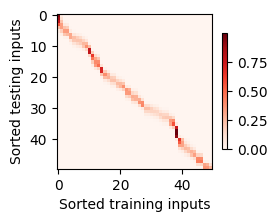

In [22]:
show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
              xlabel='Sorted training inputs',
              ylabel='Sorted testing inputs')

<details class="original-text" style="border: 1px solid #e3e3ee; border-radius: 4px; margin: 20px 0; overflow: hidden;">
  <summary style="padding: 10px 14px; font-weight: 500; cursor: pointer; background-color: #f8f8fa; list-style: none; color: #374151; font-size: 14px; letter-spacing: 0.01em;">点击：查看/折叠原文</summary>
  <div class="original-content" style="padding: 14px; background-color: #ffffff; line-height: 1.65; color: #4b5563; font-size: 14px;">
    <pre style="background-color: transparent; color: #1f2937; border: 1px solid #e5e7eb; border-radius: 0; font-size: 13px; padding: 12px; margin: 0 0 10px 0; font-family: Consolas, monospace;">
d2l.show_heatmaps(net.attention_weights.unsqueeze(0).unsqueeze(0),
                  xlabel=&#x27;Sorted training inputs&#x27;,
                  ylabel=&#x27;Sorted testing inputs&#x27;)
    </pre>
  </div>
</details>

## 10.2.8.小结

* Nadaraya-Watson核回归是具有注意力机制的机器学习范例。
* Nadaraya-Watson核回归的注意力汇聚是对训练数据中输出的加权平均。从注意力的角度来看，分配给每个值的注意力权重取决于将值所对应的键和查询作为输入的函数。
* 注意力汇聚可以分为非参数型和带参数型。

## 10.2.9.练习

1. 增加训练数据的样本数量，能否得到更好的非参数的Nadaraya-Watson核回归模型？
1. 在带参数的注意力汇聚的实验中学习得到的参数$w$的价值是什么？为什么在可视化注意力权重时，它会使加权区域更加尖锐？
1. 如何将超参数添加到非参数的Nadaraya-Watson核回归中以实现更好地预测结果？
1. 为本节的核回归设计一个新的带参数的注意力汇聚模型。训练这个新模型并可视化其注意力权重。
1.（英文版 11.2 补充）Parzen 窗密度估计定义为 $\hat{p}(\mathbf{x}) = \frac{1}{n} \sum_i k(\mathbf{x}, \mathbf{x}_i)$。证明：对于二分类问题，由 Parzen 窗得到的函数 $\hat{p}(\mathbf{x}, y=1) - \hat{p}(\mathbf{x}, y=-1)$ 与 Nadaraya-Watson 分类等价。
1.（英文版 11.2 补充）用随机梯度下降学习 Nadaraya-Watson 回归中合适的核宽。如果直接用上面的估计最小化 $(f(\mathbf{x}_i) - y_i)^2$ 会发生什么？提示：$y_i$ 是计算 $f$ 的项之一。从 $f(\mathbf{x}_i)$ 的估计中移除 $(\mathbf{x}_i, y_i)$ 并优化核宽。

参考答案详见 [answers/10.02_reference_answer](./answers/10.02_reference_answer.ipynb)。

### 10.2.9.1.参考答案（PyPTO）

In [23]:
!cat answers/txt/10.02_reference_answer_pypto.txt

### 10.2.9.2.参考答案（PyTorch）

In [24]:
!cat answers/txt/10.02_reference_answer_pytorch.txt